# Logistic regression Model (Scikit-learn)

## Import libraries

In [10]:
# data handling
import pandas as pd
import numpy as np


# exploratory analysis
import matplotlib.pyplot as plt
import seaborn as sns

# model fit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import time

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# better display for dataframes
pd.set_option('display.max_columns', None)

## Step 1: Data ingestion

In [3]:
# Load splitted dataframes 
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

# Print dataframes shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (12426, 345)
y_train shape: (12426, 3)
X_val shape: (4142, 345)
y_val shape: (4142, 3)
X_test shape: (4142, 345)
y_test shape: (4142, 3)


## Step 2: Data preprocessing
### Only standardization is performed locally , feature engineering is performed in the corresponding notebook.


In [4]:
### Scale the features ###
def get_numerical_features(df, exclude_columns=None):
    """
    Extract all numerical features from a DataFrame, excluding specified columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame
    exclude_columns : list, optional
        List of column names to exclude
    
    Returns:
    --------
    list
        List of numerical column names
    """
    # Get all numerical columns
    numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    # Remove excluded columns (DATE)
    if exclude_columns:
        numerical_features = [col for col in numerical_features if col not in exclude_columns]
    
    print(f"Found {len(numerical_features)} numerical features")
    
    return numerical_features


# Create copies of the original DataFrames
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Exclude DATE column
exclude_columns = ['DATE']
numerical_features = get_numerical_features(X_train, exclude_columns=exclude_columns)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_val_scaled[numerical_features] = scaler.transform(X_val[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

'''
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_with_lags)
X_val_scaled = scaler.transform(X_val_with_lags)
X_test_scaled = scaler.transform(X_test_with_lags)
'''

# Verify normalization - calculate means and standard deviations
means = X_train_scaled[numerical_features].mean().mean()
stds = X_train_scaled[numerical_features].std().mean()

print(f"\nStandardization verification:")
print(f"Mean of scaled features (should be close to 0): {means:.6f}")
print(f"Std of scaled features (should be close to 1): {stds:.6f}")

# Show a sample of the normalized data (5 rows, 5 columns)
sample_cols = numerical_features[:5]  # First 5 numerical columns
print("\nSample of scaled data (first 5 rows, 5 columns):")
display(X_train_scaled[sample_cols].head())

Found 312 numerical features

Standardization verification:
Mean of scaled features (should be close to 0): 0.000000
Std of scaled features (should be close to 1): 1.000040

Sample of scaled data (first 5 rows, 5 columns):


,T2M_0401,T2M_MAX_0401,T2M_MIN_0401,QV2M_0401,RH2M_0401
0,-0.408764,-0.132269,-0.498232,0.353499,0.991382
1,-0.095992,0.050615,-0.123490,0.531236,0.843568
2,0.248796,0.372631,0.378556,1.162384,1.121743
3,0.108418,0.278126,0.127533,1.042683,1.211383
4,0.033303,0.280752,0.062984,0.922983,1.145013


## Step 3: Exploratory data analysis (EDA)
### EDA is performed in the corresponding notebook.

## Step 4: Modeling

In [5]:
# Create the Scikit-learn logistic regression models
def train_fire_prediction_models(X_train, X_val, y_train, y_val, 
                                target_cols=['y_3', 'y_7', 'y_14']):
    """
    Train logistic regression models for multiple fire prediction horizons.
    
    Parameters:
    -----------
    X_train, X_val : pandas DataFrames
        Feature sets for training and validation
    y_train, y_val : pandas DataFrames
        Target variables containing columns for different prediction horizons
    target_cols : list of str
        Target column names representing different prediction horizons
    
    Returns:
    --------
    dict
        Dictionary containing trained models and training information
    """
    # Prepare data
    X_train_final = X_train.drop('DATE', axis=1, errors='ignore')
    X_val_final = X_val.drop('DATE', axis=1, errors='ignore')
    
    # Dictionary to store results
    training_results = {
        'models': {},
        'class_weights': {},
        'training_info': pd.DataFrame(columns=['Training Time (s)', 'Validation Accuracy']),
        'unique_classes': {}
    }
    
    # Train models for each target
    for target in target_cols:
        print(f"\nTraining model for {target}...")
        
        # Get target data
        y_train_target = y_train[target]
        y_val_target = y_val[target]
        
        # Compute class weights
        unique_classes = np.unique(y_train_target)
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=unique_classes,
            y=y_train_target
        )
        class_weight_dict = {int(class_idx): weight for class_idx, weight in zip(unique_classes, class_weights)}
        
        # Store unique classes and weights for this target
        training_results['unique_classes'][target] = unique_classes
        training_results['class_weights'][target] = class_weight_dict
        
        # Create and train model
        start_time = time.time()
        model = LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            C=1.0,
            class_weight=class_weight_dict,
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_final, y_train_target)
        train_time = time.time() - start_time
        
        # Calculate validation accuracy
        val_accuracy = model.score(X_val_final, y_val_target)
        
        # Store model and training info
        training_results['models'][target] = model
        training_results['training_info'].loc[target] = [train_time, val_accuracy]
        
        print(f"  Training completed in {train_time:.2f} seconds")
        print(f"  Validation accuracy: {val_accuracy:.4f}")
        
    return training_results

In [6]:
# Training models
training_results = train_fire_prediction_models(
    X_train_scaled, X_val_scaled, 
    y_train, y_val,
    target_cols=['y_3', 'y_7', 'y_14']
)


Training model for y_3...
  Training completed in 17.38 seconds
  Validation accuracy: 0.4845

Training model for y_7...
  Training completed in 14.72 seconds
  Validation accuracy: 0.3257

Training model for y_14...
  Training completed in 15.18 seconds
  Validation accuracy: 0.2492


## Step 5: Experiments
### This is the baseline model, tuning is not performed.

## Step 6: Evaluation and generalization

In [7]:
# Create the evaluation function
def evaluate_fire_prediction_models(training_results, X_test, y_test, 
                                   target_cols=['y_3', 'y_7', 'y_14'],
                                   label_dict={0:'No fire',1: '0401', 2:'0402', 3:'0403', 
                                              4:'0404', 5: '0405', 6:'0406', 7:'0407'},
                                   metrics_average='weighted'):
    """
    Evaluate trained models and generate performance visualizations.
    
    Parameters:
    -----------
    training_results : dict
        Dictionary containing trained models from train_fire_prediction_models
    X_test : pandas DataFrame
        Test feature set
    y_test : pandas DataFrame
        Test target variables
    target_cols : list of str
        Target column names representing different prediction horizons
    label_dict : dict
        Dictionary mapping numeric class labels to meaningful names
    metrics_average : str
        Averaging method for precision/recall metrics ('weighted', 'macro', 'micro')
    
    Returns:
    --------
    dict
        Dictionary containing evaluation metrics and figures
    """
    # Prepare data
    X_test_final = X_test.drop('DATE', axis=1, errors='ignore')
    
    # Dictionary to store results
    eval_results = {
        'metrics': pd.DataFrame(columns=['Accuracy', 'Precision', 'Recall', 'F1']),
        'predictions': {},
        'figures': {}
    }
    
    # Set up figure for confusion matrices
    confusion_fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Evaluate models for each target
    for i, target in enumerate(target_cols):
        print(f"\nEvaluating model for {target}...")
        
        # Get model and test data
        model = training_results['models'][target]
        y_test_target = y_test[target]
        
        # Make predictions
        y_pred = model.predict(X_test_final)
        eval_results['predictions'][target] = y_pred
        
        # Calculate metrics
        accuracy = accuracy_score(y_test_target, y_pred)
        precision = precision_score(y_test_target, y_pred, average=metrics_average)
        recall = recall_score(y_test_target, y_pred, average=metrics_average)
        f1 = f1_score(y_test_target, y_pred, average=metrics_average)
        
        # Store metrics
        eval_results['metrics'].loc[target] = [accuracy, precision, recall, f1]
        
        # Print metrics
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision ({metrics_average}): {precision:.4f}")
        print(f"  Recall ({metrics_average}): {recall:.4f}")
        print(f"  F1 ({metrics_average}): {f1:.4f}")
        
        # Map numeric labels to meaningful names
        y_test_mapped = pd.Series(y_test_target).map(label_dict)
        y_pred_mapped = pd.Series(y_pred).map(label_dict)
        
        # Get unique classes in the order they appear in the label dictionary
        unique_classes = training_results['unique_classes'][target]
        classes_in_data = [label_dict[c] for c in sorted(unique_classes) if c in label_dict]
        
        # Plot confusion matrix
        cm = pd.crosstab(
            y_test_mapped, 
            y_pred_mapped, 
            rownames=['Actual'], 
            colnames=['Predicted'],
            normalize='index'  # Normalize by row (actual class)
        )
        
        # Ensure all classes are represented in the confusion matrix
        for cls in classes_in_data:
            if cls not in cm.index:
                cm.loc[cls] = 0
            if cls not in cm.columns:
                cm[cls] = 0
        
        # Sort the confusion matrix to match the label dictionary order
        cm = cm.loc[classes_in_data][classes_in_data]
        
        # Plot labels
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[i], 
                   cbar=False, annot_kws={"size": 8})
        axes[i].set_title(f'Prediction Horizon: {target.replace("y_", "")} days')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=8)
        axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=8)
    
    # Add sup title to confusion matrices
    plt.figure(confusion_fig.number)
    plt.suptitle('Fire Prediction Model Comparison', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    eval_results['figures']['confusion'] = confusion_fig
    
    # Create a comparative metrics chart
    metrics_fig = plt.figure(figsize=(10, 6))
    
    # Rename the index 
    display_metrics = eval_results['metrics'].copy()
    display_metrics.index = [f"{col.replace('y_', '')} Day Forecast" for col in display_metrics.index]
    
    # Plot metrics
    display_metrics.plot(kind='bar', figsize=(10, 5))
    plt.title('Model Performance Comparison')
    plt.ylabel('Score')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(loc='upper right')
    
    # Add value labels
    for i, v in enumerate(display_metrics['Accuracy']):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    
    plt.tight_layout()
    eval_results['figures']['metrics'] = metrics_fig
    
    # Create a summary table for the slide
    results_table = plt.figure(figsize=(10, 3))
    plt.axis('off')
    
    # Add a table with key metrics
    table_data = eval_results['metrics'].round(3)
    table_data.index = [f"{col.replace('y_', '')} Day Forecast" for col in table_data.index]
    
    # Create the table
    table = plt.table(
        cellText=table_data.values,
        rowLabels=table_data.index,
        colLabels=table_data.columns,
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Add a title
    plt.title('Performance Metrics Summary', pad=20, fontsize=14)
    eval_results['figures']['table'] = results_table
    
    # Return evaluation results
    return eval_results


Evaluating model for y_3...
  Accuracy: 0.4529
  Precision (weighted): 0.5062
  Recall (weighted): 0.4529
  F1 (weighted): 0.4733

Evaluating model for y_7...
  Accuracy: 0.3204
  Precision (weighted): 0.4042
  Recall (weighted): 0.3204
  F1 (weighted): 0.3485

Evaluating model for y_14...
  Accuracy: 0.2323
  Precision (weighted): 0.3176
  Recall (weighted): 0.2323
  F1 (weighted): 0.2602

Model Performance Summary:
      Accuracy  Precision  Recall     F1
y_3      0.453      0.506   0.453  0.473
y_7      0.320      0.404   0.320  0.349
y_14     0.232      0.318   0.232  0.260


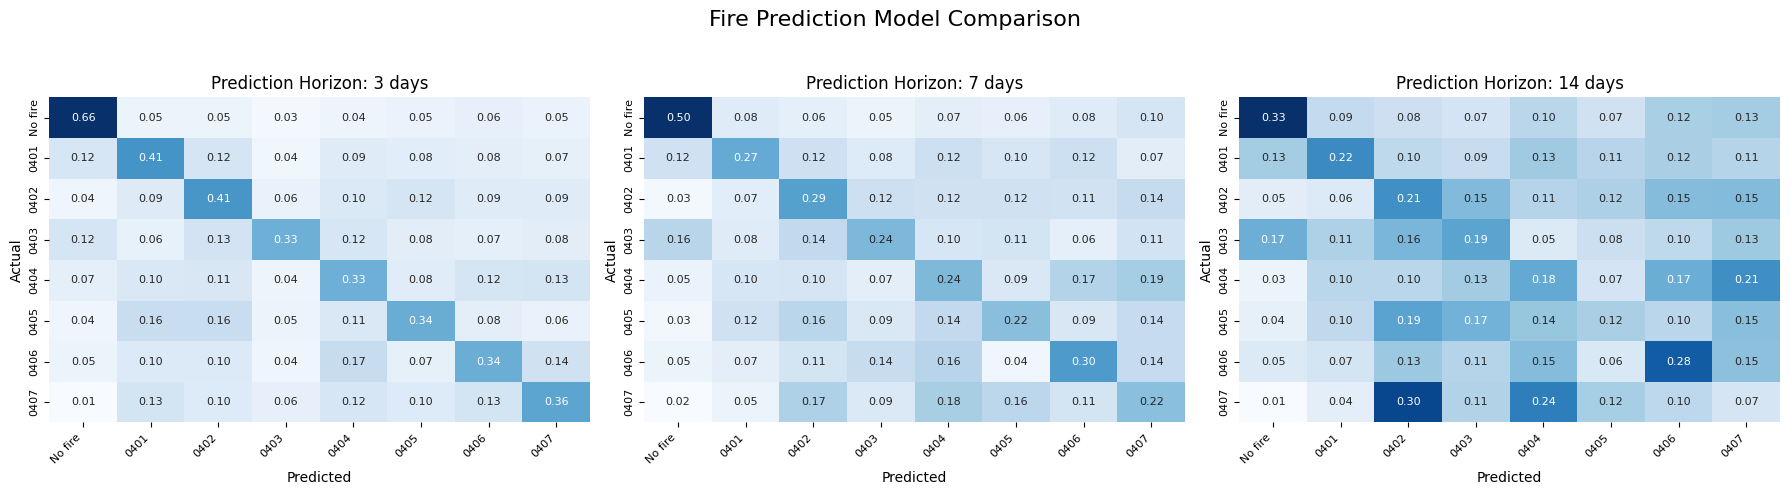

<Figure size 1000x600 with 0 Axes>

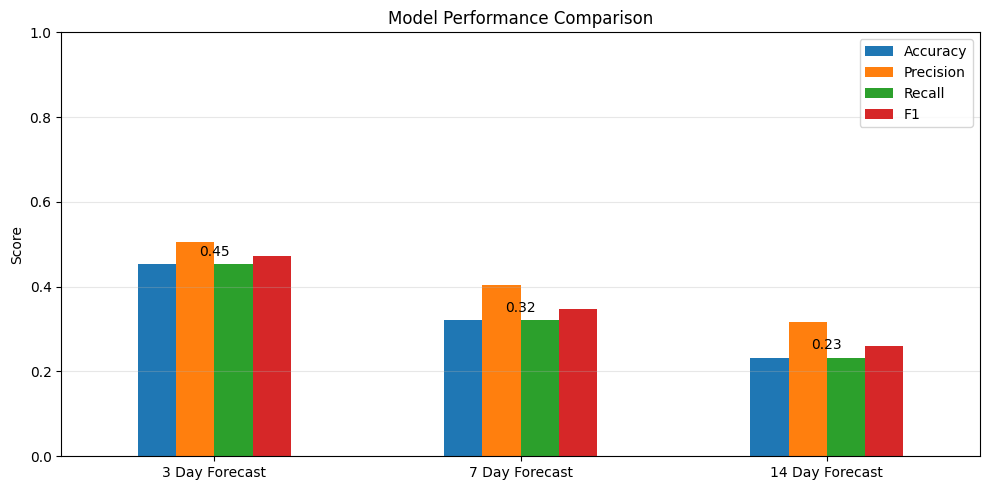

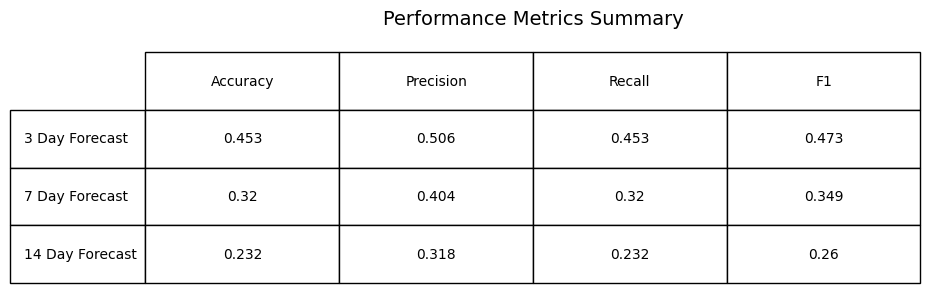

In [8]:
# Evaluating models
eval_results = evaluate_fire_prediction_models(
    training_results, 
    X_test_scaled, y_test,
    target_cols=['y_3', 'y_7', 'y_14'],
    label_dict={0:'No fire',1: '0401', 2:'0402', 3:'0403', 4:'0404',5: '0405', 6:'0406', 7:'0407'},
    metrics_average='weighted' 
)

# Display figures
eval_results['figures']['confusion'].show()
eval_results['figures']['metrics'].show()
eval_results['figures']['table'].show()

# Print summary
print("\nModel Performance Summary:")
print(eval_results['metrics'].round(3))